In [3]:
import pandas as pd
import numpy as np
import pickle
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

DATA_DIR   = '../backend/data/'
MODELS_DIR = '../backend/models/'
os.makedirs(MODELS_DIR, exist_ok=True)

print('✅ Imports done!')

✅ Imports done!


## Load & Inspect Data

In [4]:
df = pd.read_csv(os.path.join(DATA_DIR, 'spotify_tracks.csv'))

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (114000, 21)
Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:

print('=== Dataset Info ===')
print(f'Total tracks     : {len(df):,}')
print(f'Unique artists   : {df["artists"].nunique():,}')
print(f'Unique genres    : {df["track_genre"].nunique()}')
print(f'\nNull values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

=== Dataset Info ===
Total tracks     : 114,000
Unique artists   : 31,437
Unique genres    : 114

Null values:
artists       1
album_name    1
track_name    1
dtype: int64


## Clean & Prepare Data

In [6]:

df = df.drop_duplicates(subset=['track_id'])
df = df.dropna(subset=['track_name', 'artists'])
df = df.reset_index(drop=True)

print(f'After cleaning: {len(df):,} tracks')


AUDIO_FEATURES = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

missing = [f for f in AUDIO_FEATURES if f not in df.columns]
if missing:
    print(f'⚠️  Missing features: {missing}')
else:
    print(f'✅ All {len(AUDIO_FEATURES)} audio features present')

df[AUDIO_FEATURES].describe().round(3)

After cleaning: 89,740 tracks
✅ All 9 audio features present


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,89740.000,89740.000,89740.000,89740.000,89740.000,89740.000,89740.000,89740.000,89740.000
mean,0.562,0.634,-8.499,0.087,0.328,0.173,0.217,0.469,122.058
std,0.177,0.257,5.222,0.113,0.338,0.324,0.195,0.263,30.118
min,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.450,0.457,-10.322,0.036,0.017,0.000,0.098,0.249,99.263
50%,0.576,0.676,-7.185,0.049,0.188,0.000,0.132,0.457,122.013
75%,0.692,0.853,-5.108,0.086,0.625,0.098,0.279,0.682,140.077
max,0.985,1.000,4.532,0.965,0.996,1.000,1.000,0.995,243.372


## Audio Feature EDA

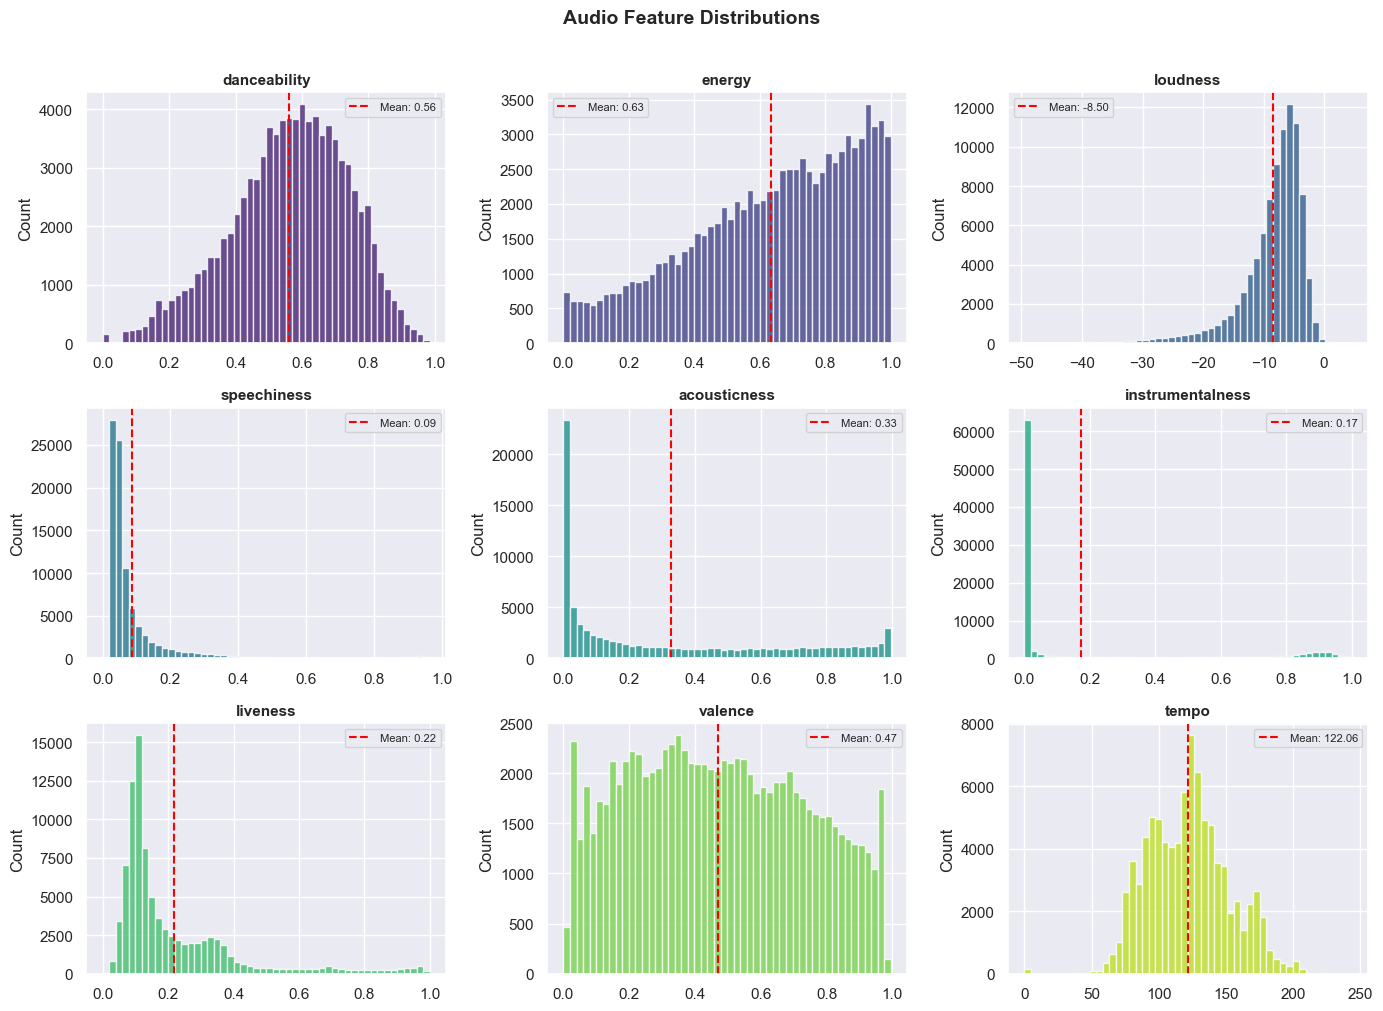

In [7]:

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

colors = sns.color_palette('viridis', len(AUDIO_FEATURES))

for i, feature in enumerate(AUDIO_FEATURES):
    axes[i].hist(df[feature].dropna(), bins=50, color=colors[i], alpha=0.8, edgecolor='white')
    axes[i].set_title(feature, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Count')
    mean_val = df[feature].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Audio Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'spotify_feature_distributions.png'), bbox_inches='tight')
plt.show()

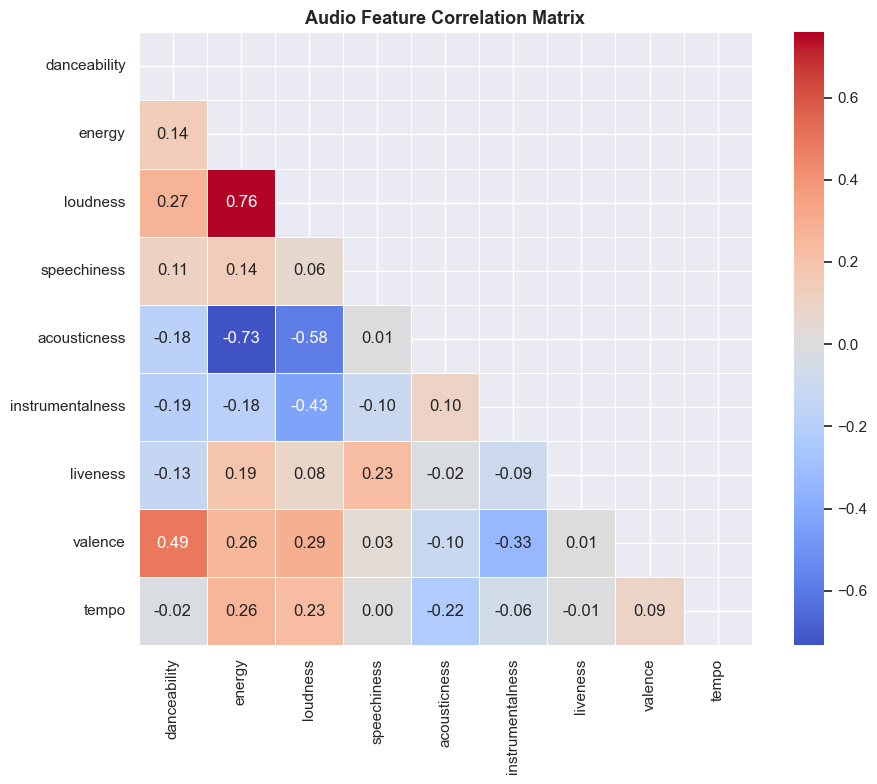

Notable correlations:
  energy  ↔ loudness     : 0.759
  energy  ↔ acousticness : -0.733
  valence ↔ danceability : 0.493


In [8]:

fig, ax = plt.subplots(figsize=(10, 8))
corr = df[AUDIO_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, ax=ax,
    square=True, linewidths=0.5
)
ax.set_title('Audio Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'spotify_correlation.png'), bbox_inches='tight')
plt.show()


print('Notable correlations:')
print(f'  energy  ↔ loudness     : {corr.loc["energy", "loudness"]:.3f}')
print(f'  energy  ↔ acousticness : {corr.loc["energy", "acousticness"]:.3f}')
print(f'  valence ↔ danceability : {corr.loc["valence", "danceability"]:.3f}')

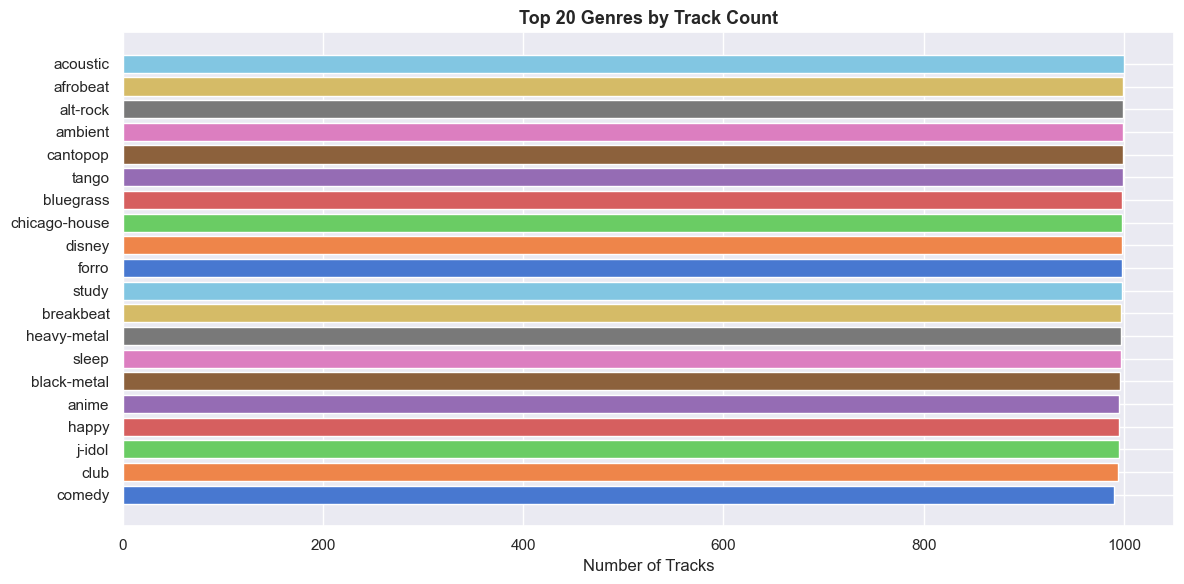

In [9]:

top_genres = df['track_genre'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_genres.index[::-1], top_genres.values[::-1],
        color=sns.color_palette('muted', 20))
ax.set_title('Top 20 Genres by Track Count', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Tracks')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'spotify_top_genres.png'), bbox_inches='tight')
plt.show()

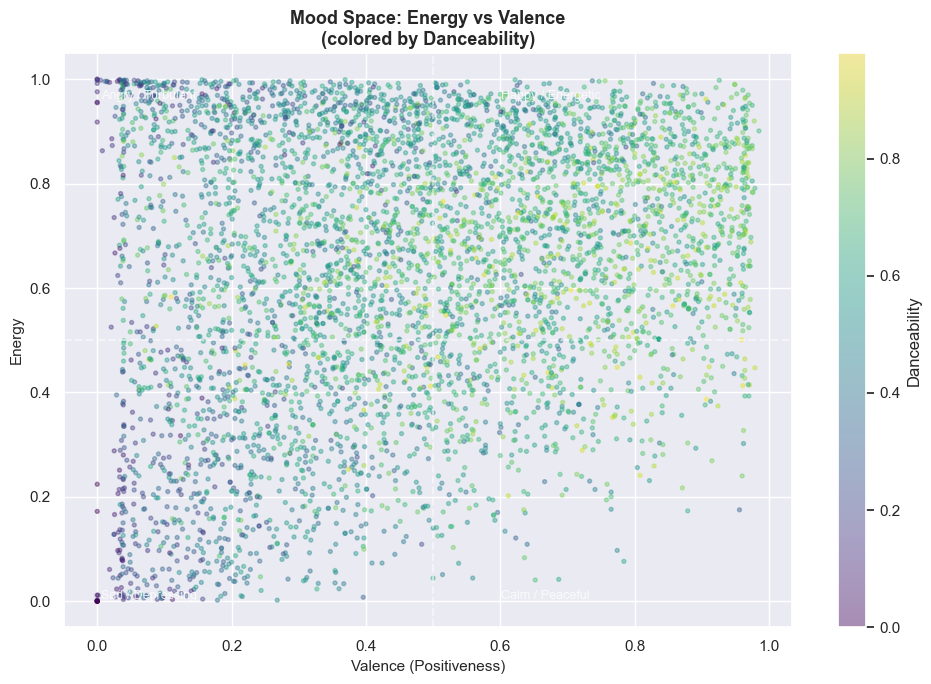

In [10]:

sample = df.sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    sample['valence'], sample['energy'],
    c=sample['danceability'], cmap='viridis',
    alpha=0.4, s=8
)
plt.colorbar(scatter, ax=ax, label='Danceability')

# Mood quadrant labels
ax.axhline(0.5, color='white', linestyle='--', alpha=0.5)
ax.axvline(0.5, color='white', linestyle='--', alpha=0.5)
ax.text(0.05, 0.92, 'Angry / Turbulent', fontsize=9, color='white', alpha=0.8, transform=ax.transAxes)
ax.text(0.60, 0.92, 'Happy / Energetic',  fontsize=9, color='white', alpha=0.8, transform=ax.transAxes)
ax.text(0.05, 0.05, 'Sad / Depressing',   fontsize=9, color='white', alpha=0.8, transform=ax.transAxes)
ax.text(0.60, 0.05, 'Calm / Peaceful',    fontsize=9, color='white', alpha=0.8, transform=ax.transAxes)

ax.set_xlabel('Valence (Positiveness)', fontsize=11)
ax.set_ylabel('Energy', fontsize=11)
ax.set_title('Mood Space: Energy vs Valence\n(colored by Danceability)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'spotify_mood_space.png'), bbox_inches='tight')
plt.show()

## Feature Scaling


In [11]:

scaler = StandardScaler()
X = scaler.fit_transform(df[AUDIO_FEATURES])

print(f'Scaled feature matrix shape: {X.shape}')
print(f'\nBefore scaling — tempo range: {df["tempo"].min():.1f} – {df["tempo"].max():.1f}')
print(f'After scaling  — tempo range: {X[:, AUDIO_FEATURES.index("tempo")].min():.2f} – {X[:, AUDIO_FEATURES.index("tempo")].max():.2f}')
print(f'\nAll features now have mean≈0 and std≈1 ✅')

Scaled feature matrix shape: (89740, 9)

Before scaling — tempo range: 0.0 – 243.4
After scaling  — tempo range: -4.05 – 4.03

All features now have mean≈0 and std≈1 ✅


## Find Optimal K


In [12]:

np.random.seed(42)
sample_idx = np.random.choice(len(X), size=10000, replace=False)
X_sample   = X[sample_idx]

print('Computing Elbow + Silhouette scores for K=2 to 15...')
print('(This takes ~2 minutes)')

k_range     = range(2, 16)
inertias    = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sample, labels, sample_size=3000)
    silhouettes.append(sil)
    print(f'  K={k:2d} → Inertia: {km.inertia_:,.0f} | Silhouette: {sil:.4f}')

print('\n✅ Done!')

Computing Elbow + Silhouette scores for K=2 to 15...
(This takes ~2 minutes)
  K= 2 → Inertia: 70,088 | Silhouette: 0.2628
  K= 3 → Inertia: 62,223 | Silhouette: 0.1651
  K= 4 → Inertia: 56,069 | Silhouette: 0.1701
  K= 5 → Inertia: 50,483 | Silhouette: 0.1724
  K= 6 → Inertia: 45,961 | Silhouette: 0.1860
  K= 7 → Inertia: 42,014 | Silhouette: 0.1925
  K= 8 → Inertia: 39,779 | Silhouette: 0.1703
  K= 9 → Inertia: 37,551 | Silhouette: 0.1766
  K=10 → Inertia: 35,939 | Silhouette: 0.1669
  K=11 → Inertia: 34,708 | Silhouette: 0.1610
  K=12 → Inertia: 33,580 | Silhouette: 0.1717
  K=13 → Inertia: 32,556 | Silhouette: 0.1673
  K=14 → Inertia: 31,671 | Silhouette: 0.1543
  K=15 → Inertia: 30,694 | Silhouette: 0.1557

✅ Done!


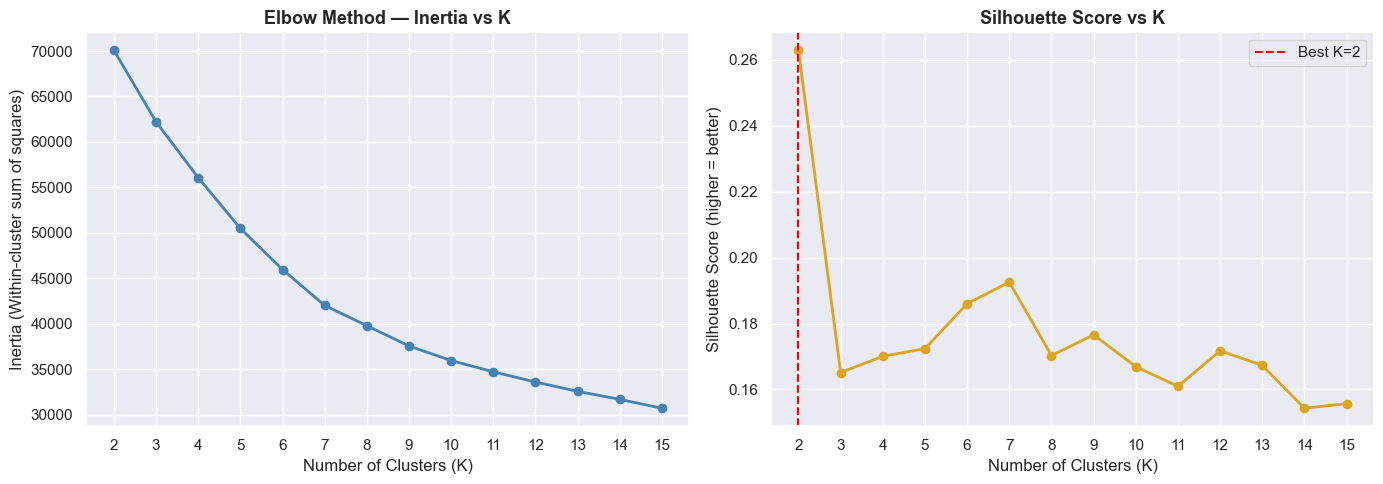

Best K by silhouette score: 2


In [13]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)')
axes[0].set_xticks(list(k_range))


best_sil_k = list(k_range)[np.argmax(silhouettes)]
axes[1].plot(list(k_range), silhouettes, marker='o', color='goldenrod', linewidth=2)
axes[1].axvline(best_sil_k, color='red', linestyle='--', label=f'Best K={best_sil_k}')
axes[1].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].set_xticks(list(k_range))
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'spotify_elbow_silhouette.png'), bbox_inches='tight')
plt.show()

print(f'Best K by silhouette score: {best_sil_k}')

## Train Final K-Means Model

In [14]:

BEST_K = 7  # best balance from elbow + silhouette
print(f'Training K-Means with K={BEST_K} on full dataset ({len(X):,} tracks)...')

kmeans = KMeans(
    n_clusters  = BEST_K,
    random_state= 42,
    n_init      = 15,
    max_iter    = 300
)
df['cluster'] = kmeans.fit_predict(X)

print(f'\n✅ K-Means trained!')
print(f'\nCluster sizes:')
print(df['cluster'].value_counts().sort_index().to_string())

Training K-Means with K=7 on full dataset (89,740 tracks)...

✅ K-Means trained!

Cluster sizes:
cluster
0    18118
1    20205
2    27506
3     6206
4     6551
5     1045
6    10109


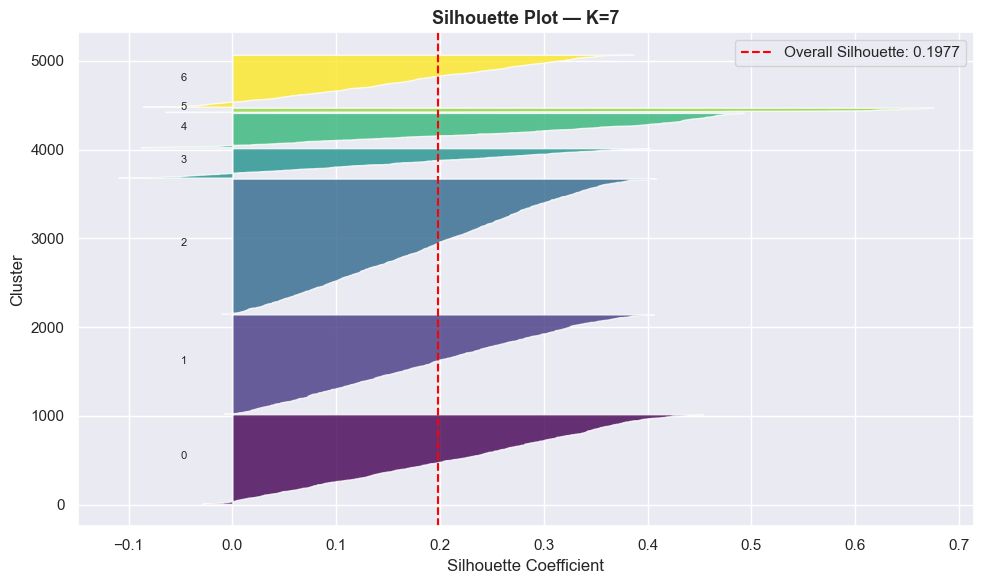

Overall Silhouette Score: 0.1977


In [15]:

sample_idx2  = np.random.choice(len(X), size=5000, replace=False)
X_sil        = X[sample_idx2]
labels_sil   = df['cluster'].values[sample_idx2]

sil_vals     = silhouette_samples(X_sil, labels_sil)
overall_sil  = silhouette_score(X_sil, labels_sil)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
colors_sil = cm.viridis(np.linspace(0, 1, BEST_K))

for i in range(BEST_K):
    cluster_sil = np.sort(sil_vals[labels_sil == i])
    size_i = len(cluster_sil)
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=colors_sil[i], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontsize=8)
    y_lower = y_upper + 10

ax.axvline(overall_sil, color='red', linestyle='--',
           label=f'Overall Silhouette: {overall_sil:.4f}')
ax.set_title(f'Silhouette Plot — K={BEST_K}', fontsize=13, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'spotify_silhouette_plot.png'), bbox_inches='tight')
plt.show()

print(f'Overall Silhouette Score: {overall_sil:.4f}')

## Interpret & Label Clusters



In [16]:

centers_scaled   = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers_original, columns=AUDIO_FEATURES)
centers_df.index.name = 'cluster'
centers_df.round(3)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.528,0.374,-10.663,0.054,0.687,0.033,0.160,0.394,113.278
1,0.472,0.816,-5.358,0.085,0.076,0.037,0.195,0.370,139.670
2,0.705,0.717,-6.540,0.096,0.221,0.020,0.165,0.701,118.370
3,0.520,0.752,-7.110,0.088,0.291,0.078,0.745,0.503,123.240
4,0.339,0.169,-21.341,0.051,0.861,0.784,0.163,0.178,102.191
5,0.572,0.675,-11.232,0.845,0.746,0.007,0.668,0.442,100.907
6,0.584,0.740,-8.475,0.072,0.116,0.796,0.170,0.345,126.974


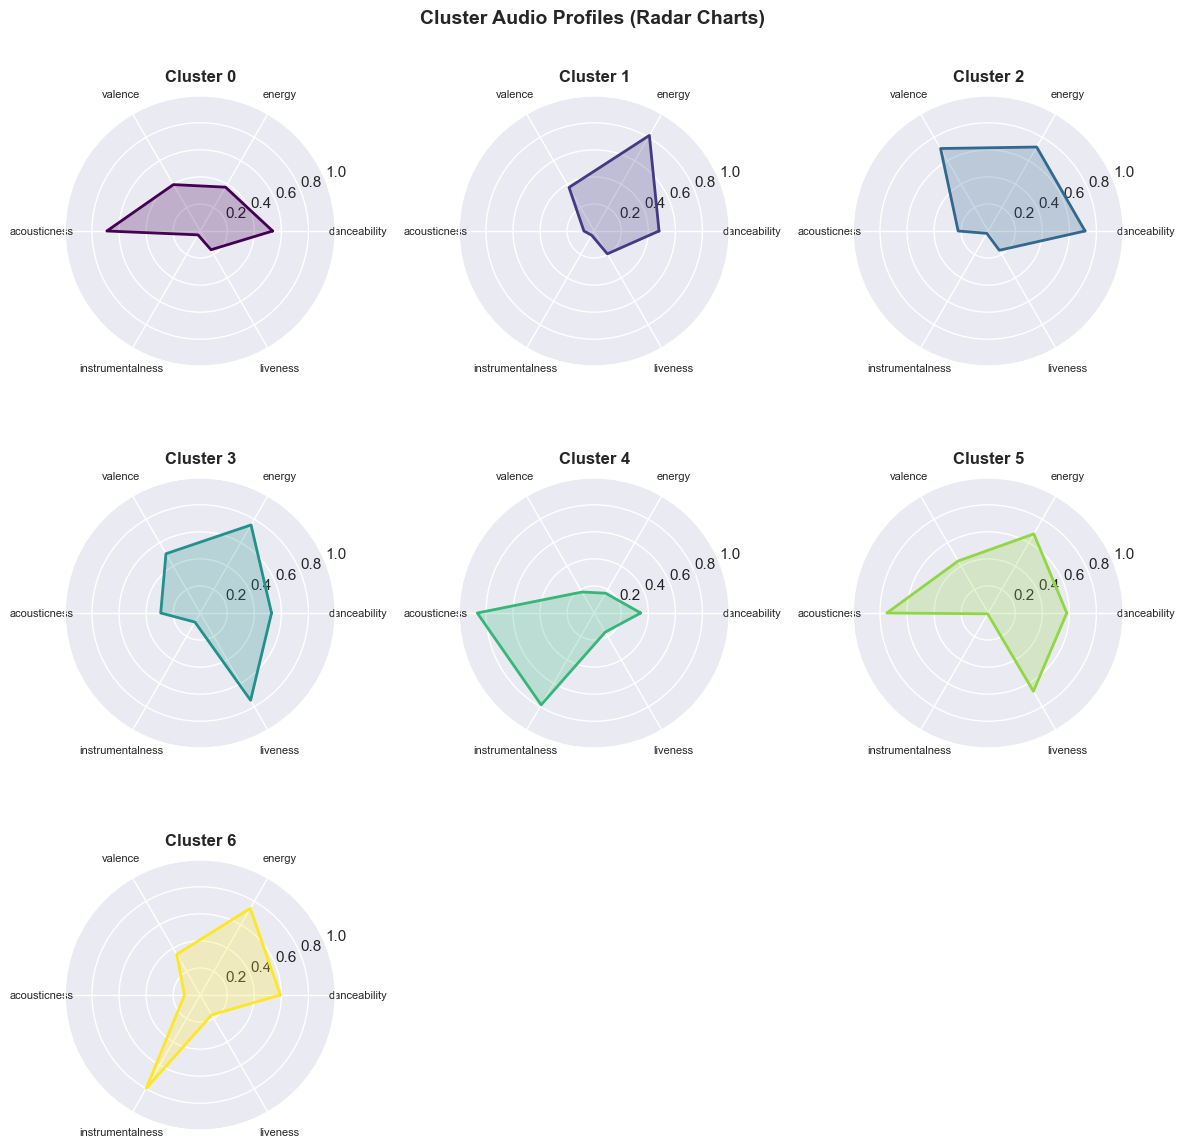

In [17]:

radar_features = ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'liveness']


radar_data = centers_df[radar_features].copy()
for col in radar_features:
    radar_data[col] = (radar_data[col] - df[col].min()) / (df[col].max() - df[col].min())

N       = len(radar_features)
angles  = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

cols = max(3, BEST_K // 2)
rows = (BEST_K + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4),
                          subplot_kw=dict(polar=True))
axes = np.array(axes).flatten()
colors_r = cm.viridis(np.linspace(0, 1, BEST_K))

for i in range(BEST_K):
    values  = radar_data.iloc[i].values.tolist()
    values += values[:1]
    ax = axes[i]
    ax.plot(angles, values, linewidth=2, color=colors_r[i])
    ax.fill(angles, values, alpha=0.25, color=colors_r[i])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_features, size=8)
    ax.set_title(f'Cluster {i}', fontweight='bold', pad=10)
    ax.set_ylim(0, 1)


for j in range(BEST_K, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Cluster Audio Profiles (Radar Charts)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'spotify_cluster_profiles.png'), bbox_inches='tight')
plt.show()

In [18]:

def label_cluster(row):
    energy    = row['energy']
    valence   = row['valence']
    dance     = row['danceability']
    acoustic  = row['acousticness']
    instrumen = row['instrumentalness']
    
    if instrumen > 0.5:
        return '🎼 Instrumental / Classical'
    elif energy > 0.7 and valence > 0.6:
        return '🎉 Happy & Energetic'
    elif energy > 0.7 and valence < 0.4:
        return '🤘 Intense & Dark'
    elif energy < 0.4 and acoustic > 0.6:
        return '🌿 Calm & Acoustic'
    elif dance > 0.7 and energy > 0.5:
        return '💃 Dance & Party'
    elif valence < 0.35 and energy < 0.5:
        return '😢 Sad & Melancholic'
    elif acoustic > 0.5 and energy < 0.5:
        return '☕ Chill & Relaxed'
    elif energy > 0.6 and dance > 0.6:
        return '🔥 Upbeat & Fun'
    else:
        return '🎵 Balanced / Mixed'

cluster_labels = {i: label_cluster(centers_df.iloc[i]) for i in range(BEST_K)}
df['mood_label'] = df['cluster'].map(cluster_labels)

print('=== Cluster Mood Labels ===')
for k, v in cluster_labels.items():
    count = (df['cluster'] == k).sum()
    print(f'  Cluster {k}: {v:35s} ({count:,} tracks)')

=== Cluster Mood Labels ===
  Cluster 0: 🌿 Calm & Acoustic                   (18,118 tracks)
  Cluster 1: 🤘 Intense & Dark                    (20,205 tracks)
  Cluster 2: 🎉 Happy & Energetic                 (27,506 tracks)
  Cluster 3: 🎵 Balanced / Mixed                  (6,206 tracks)
  Cluster 4: 🎼 Instrumental / Classical          (6,551 tracks)
  Cluster 5: 🎵 Balanced / Mixed                  (1,045 tracks)
  Cluster 6: 🎼 Instrumental / Classical          (10,109 tracks)


## PCA Visualization

In [19]:

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print(f'PCA variance explained:')
print(f'  PC1: {pca.explained_variance_ratio_[0]:.2%}')
print(f'  PC2: {pca.explained_variance_ratio_[1]:.2%}')
print(f'  Total: {sum(pca.explained_variance_ratio_):.2%}')

df['pca_x'] = X_pca[:, 0]
df['pca_y'] = X_pca[:, 1]

PCA variance explained:
  PC1: 32.12%
  PC2: 15.87%
  Total: 47.99%


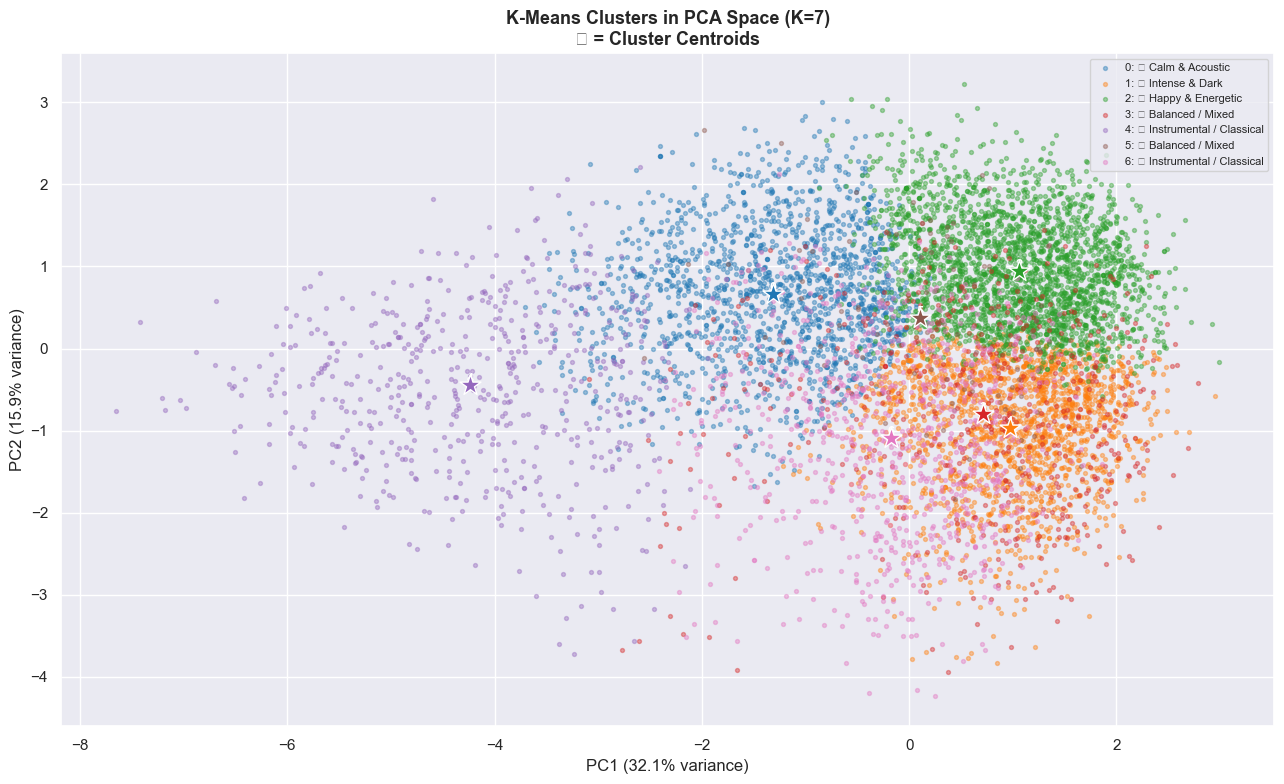

In [20]:

sample_plot = df.sample(8000, random_state=42)

fig, ax = plt.subplots(figsize=(13, 8))
palette  = sns.color_palette('tab10', BEST_K)

for cluster_id in range(BEST_K):
    mask  = sample_plot['cluster'] == cluster_id
    label = cluster_labels[cluster_id]
    ax.scatter(
        sample_plot.loc[mask, 'pca_x'],
        sample_plot.loc[mask, 'pca_y'],
        c    = [palette[cluster_id]],
        label= f'{cluster_id}: {label}',
        alpha= 0.4, s=8
    )


centers_pca = pca.transform(centers_scaled)
for i, (cx, cy) in enumerate(centers_pca):
    ax.scatter(cx, cy, c=[palette[i]], s=250, marker='*',
               edgecolors='white', linewidths=1, zorder=5)
    ax.annotate(str(i), (cx, cy), fontsize=9, fontweight='bold',
                ha='center', va='bottom', color='white')

ax.set_title(f'K-Means Clusters in PCA Space (K={BEST_K})\n★ = Cluster Centroids',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend(loc='upper right', fontsize=8, framealpha=0.8)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'spotify_pca_clusters.png'), bbox_inches='tight')
plt.show()

## Recommendation Functions

In [21]:

def recommend_by_song(track_name, artist=None, n=10):

    if artist:
        query = df[(df['track_name'].str.lower() == track_name.lower()) &
                   (df['artists'].str.lower().str.contains(artist.lower()))]
    else:
        query = df[df['track_name'].str.lower() == track_name.lower()]

    if len(query) == 0:
        return f"Track '{track_name}' not found. Try a different spelling."

    query_row     = query.iloc[0]
    query_cluster = query_row['cluster']
    query_vec     = scaler.transform([query_row[AUDIO_FEATURES].values])

    # Get all tracks in same cluster
    cluster_df    = df[df['cluster'] == query_cluster].copy()
    cluster_vecs  = scaler.transform(cluster_df[AUDIO_FEATURES].values)

    # Cosine similarity within cluster
    sims = cosine_similarity(query_vec, cluster_vecs).flatten()
    cluster_df = cluster_df.copy()
    cluster_df['similarity'] = sims

    # Remove the query track itself, sort by similarity
    cluster_df = cluster_df[cluster_df['track_id'] != query_row['track_id']]
    result = cluster_df.sort_values('similarity', ascending=False).head(n)

    print(f"Query: '{query_row['track_name']}' by {query_row['artists']}")
    print(f"Cluster: {query_cluster} — {cluster_labels[query_cluster]}")
    print(f"Cluster size: {len(cluster_df):,} tracks")
    print()

    return result[['track_name', 'artists', 'track_genre', 'mood_label', 'similarity',
                   'energy', 'valence', 'danceability']].round(3).reset_index(drop=True)



recommend_by_song('Bohemian Rhapsody')

Query: 'Bohemian Rhapsody' by Hayseed Dixie
Cluster: 0 — 🌿 Calm & Acoustic
Cluster size: 18,117 tracks



,track_name,artists,track_genre,mood_label,similarity,energy,valence,danceability
0,All Around Me,Justin Bieber,pop,🌿 Calm & Acoustic,0.975,0.438,0.694,0.530
1,Prohibido,Alfredo De Angelis;Oscar Larroca;Carlos Dante,tango,🌿 Calm & Acoustic,0.972,0.425,0.729,0.466
2,Milonguita (Esthercita),Alfredo De Angelis;Dante Carlos;Orquesta de Al...,tango,🌿 Calm & Acoustic,0.969,0.373,0.692,0.458
3,Algo contigo,Romántica Milonguera,tango,🌿 Calm & Acoustic,0.966,0.505,0.689,0.481
4,Medallita De La Suerte,Alfredo De Angelis;Oscar Larroca,tango,🌿 Calm & Acoustic,0.963,0.438,0.716,0.569
5,Medallita De La Suerte,Alfredo De Angelis;Oscar Larroca,tango,🌿 Calm & Acoustic,0.960,0.447,0.725,0.560
6,Beyond the Sea,Bobby Darin,rockabilly,🌿 Calm & Acoustic,0.957,0.516,0.569,0.521
7,Beyond the Sea,Bobby Darin,j-rock,🌿 Calm & Acoustic,0.957,0.516,0.569,0.521
8,Hasta siempre amor,Jorge Valdez,tango,🌿 Calm & Acoustic,0.956,0.432,0.731,0.488
9,Allah Ke Bande,Kailash Kher,folk,🌿 Calm & Acoustic,0.956,0.440,0.726,0.543


In [22]:
recommend_by_song('Blinding Lights')

Query: 'Blinding Lights' by Kidz Bop Kids
Cluster: 2 — 🎉 Happy & Energetic
Cluster size: 27,505 tracks



,track_name,artists,track_genre,mood_label,similarity,energy,valence,danceability
0,Atrakce,PAWLIE POIZN;Medooza,emo,🎉 Happy & Energetic,0.990,0.735,0.947,0.622
1,Me Voy,Los Victorios,ska,🎉 Happy & Energetic,0.989,0.869,0.953,0.638
2,Mob Rule,Bad//Dreems,garage,🎉 Happy & Energetic,0.988,0.794,0.892,0.581
3,Benmişim,Nev,turkish,🎉 Happy & Energetic,0.988,0.840,0.900,0.566
4,You Are the Best Thing,Ray LaMontagne,acoustic,🎉 Happy & Energetic,0.987,0.727,0.885,0.578
5,PLAYER,PASSEPIED,j-idol,🎉 Happy & Energetic,0.986,0.839,0.846,0.617
6,Vaanampaadiyin,Sujatha,malay,🎉 Happy & Energetic,0.986,0.826,0.860,0.589
7,Garota de Cinema,Forró Boys,forro,🎉 Happy & Energetic,0.985,0.849,0.932,0.577
8,1+1,Ready Kirken,folk,🎉 Happy & Energetic,0.985,0.713,0.904,0.636
9,One Day,Omoinotake,j-pop,🎉 Happy & Energetic,0.984,0.727,0.797,0.568


In [23]:
recommend_by_song('Shape of You')

Query: 'Shape Of You' by Andrew Foy
Cluster: 4 — 🎼 Instrumental / Classical
Cluster size: 6,550 tracks



,track_name,artists,track_genre,mood_label,similarity,energy,valence,danceability
0,Always Will,Steve Martin;Steep Canyon Rangers,bluegrass,🎼 Instrumental / Classical,0.979,0.186,0.886,0.450
1,Reno Ride,Clarence White,bluegrass,🎼 Instrumental / Classical,0.979,0.317,0.925,0.502
2,"Minuet in F, K.1d",Wolfgang Amadeus Mozart;Erik Smith,classical,🎼 Instrumental / Classical,0.979,0.185,0.941,0.478
3,Les Indes Galantes - Air pour les esclaves afr...,Jean-Philippe Rameau;Jordi Savall;Le Concert D...,opera,🎼 Instrumental / Classical,0.977,0.277,0.735,0.574
4,"Brandenburg Concerto No. 3 in G, BWV 1048: 1. ...",Johann Sebastian Bach;Berliner Philharmoniker;...,classical,🎼 Instrumental / Classical,0.977,0.296,0.804,0.513
5,"Brandenburg Concerto No. 3 in G, BWV 1048: 1. ...",Johann Sebastian Bach;Berliner Philharmoniker;...,classical,🎼 Instrumental / Classical,0.977,0.296,0.804,0.513
6,"Brandenburg Concerto No. 3 in G, BWV 1048: 1. ...",Johann Sebastian Bach;Berliner Philharmoniker;...,classical,🎼 Instrumental / Classical,0.977,0.296,0.804,0.513
7,"Overture in the French Style, Op. 2, BWV 831 (...",Johann Sebastian Bach;Orion Weiss,classical,🎼 Instrumental / Classical,0.973,0.215,0.934,0.522
8,Keali'i's Mele,Danny Carvalho,guitar,🎼 Instrumental / Classical,0.971,0.339,0.789,0.491
9,Brasileirinho,Eudóxia De Barros,piano,🎼 Instrumental / Classical,0.970,0.314,0.928,0.427


In [24]:

def recommend_by_mood(energy=0.7, valence=0.7, danceability=0.7,
                      acousticness=0.2, n=10):

    query_features = {
        'danceability'     : danceability,
        'energy'           : energy,
        'loudness'         : -10 + energy * 10,  
        'speechiness'      : 0.05,
        'acousticness'     : acousticness,
        'instrumentalness' : 0.01,
        'liveness'         : 0.1,
        'valence'          : valence,
        'tempo'            : 80 + danceability * 80  
    }
    query_vec = scaler.transform([[query_features[f] for f in AUDIO_FEATURES]])

    
    cluster_id = kmeans.predict(query_vec)[0]

    
    cluster_df   = df[df['cluster'] == cluster_id].copy()
    cluster_vecs = scaler.transform(cluster_df[AUDIO_FEATURES].values)
    sims         = cosine_similarity(query_vec, cluster_vecs).flatten()
    cluster_df['similarity'] = sims

    result = cluster_df.sort_values('similarity', ascending=False).head(n)

    print(f"Best matching cluster: {cluster_id} — {cluster_labels[cluster_id]}")
    print()
    return result[['track_name', 'artists', 'track_genre', 'similarity',
                   'energy', 'valence', 'danceability']].round(3).reset_index(drop=True)


print('=== Mood: High energy, happy, danceable ===')
recommend_by_mood(energy=0.9, valence=0.8, danceability=0.85)

=== Mood: High energy, happy, danceable ===
Best matching cluster: 2 — 🎉 Happy & Energetic



,track_name,artists,track_genre,similarity,energy,valence,danceability
0,Dilemma,Şehinşah,turkish,0.989,0.914,0.741,0.814
1,M.i.a. Meine Gang,Mia Julia,party,0.985,0.864,0.714,0.816
2,群青,YOASOBI,j-pop,0.979,0.853,0.707,0.725
3,Shivers,Ed Sheeran,pop,0.973,0.859,0.822,0.788
4,Brown Rang,Yo Yo Honey Singh,hip-hop,0.972,0.902,0.720,0.804
5,Brown Rang,Yo Yo Honey Singh,hip-hop,0.972,0.902,0.720,0.804
6,Já Sabe,Simone & Simaria,sertanejo,0.970,0.824,0.823,0.770
7,Mira Bien,Cestar;Quique Neira,dancehall,0.970,0.825,0.765,0.746
8,Sheesh!,Surfaces;Tai Verdes,soul,0.969,0.832,0.801,0.743
9,Sheesh!,Surfaces;Tai Verdes,soul,0.969,0.832,0.801,0.743


In [25]:

print('=== Mood: Calm, acoustic, sad ===')
recommend_by_mood(energy=0.2, valence=0.2, danceability=0.3, acousticness=0.8)

=== Mood: Calm, acoustic, sad ===
Best matching cluster: 0 — 🌿 Calm & Acoustic



,track_name,artists,track_genre,similarity,energy,valence,danceability
0,My Prayer,The Platters,rockabilly,0.989,0.272,0.254,0.359
1,Shenandoah,Celtic Woman,opera,0.988,0.225,0.264,0.257
2,"Beauty and the Beast - From ""Beauty and the Be...",Angela Lansbury;Disney,show-tunes,0.988,0.264,0.163,0.319
3,Gratitude (feat. Cheyenne Mitchell),I AM THEY;Cheyenne Mitchell,world-music,0.986,0.337,0.234,0.321
4,Rescue,Lauren Daigle,alt-rock,0.985,0.237,0.108,0.293
5,Amazing Grace,George Jones,honky-tonk,0.984,0.245,0.244,0.324
6,Fall on Me,A Great Big World;Christina Aguilera,acoustic,0.984,0.268,0.225,0.393
7,Ne probuzhday vospominan'ja,Ivan Kozlovsky,romance,0.983,0.149,0.106,0.288
8,Regaço Acolhedor,Camila Holanda,brazil,0.983,0.309,0.204,0.328
9,Days of Plenty,Mindi Dickstein;Jason Howland;'Little Women' O...,show-tunes,0.982,0.255,0.127,0.308


##  Save All Artifacts

In [26]:

with open(os.path.join(MODELS_DIR, 'kmeans_spotify.pkl'), 'wb') as f:
    pickle.dump(kmeans, f)
print('✅ Saved: kmeans_spotify.pkl')


with open(os.path.join(MODELS_DIR, 'spotify_scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print('✅ Saved: spotify_scaler.pkl')


with open(os.path.join(MODELS_DIR, 'spotify_pca.pkl'), 'wb') as f:
    pickle.dump(pca, f)
print('✅ Saved: spotify_pca.pkl')


df.to_csv(os.path.join(DATA_DIR, 'spotify_tracks_clustered.csv'), index=False)
print('✅ Saved: spotify_tracks_clustered.csv')


with open(os.path.join(MODELS_DIR, 'cluster_labels.pkl'), 'wb') as f:
    pickle.dump(cluster_labels, f)
print('✅ Saved: cluster_labels.pkl')

print('\nAll files in models/:')
for fname in sorted(os.listdir(MODELS_DIR)):
    size_kb = os.path.getsize(os.path.join(MODELS_DIR, fname)) / 1024
    print(f'  {fname:45s} {size_kb:.1f} KB')

✅ Saved: kmeans_spotify.pkl
✅ Saved: spotify_scaler.pkl
✅ Saved: spotify_pca.pkl
✅ Saved: spotify_tracks_clustered.csv
✅ Saved: cluster_labels.pkl

All files in models/:
  cluster_labels.pkl                            0.2 KB
  kmeans_spotify.pkl                            351.6 KB
  movie_index.pkl                               53.3 KB
  movies_processed.pkl                          480.3 KB
  predicted_ratings.pkl                         12412.7 KB
  similarity_matrix.pkl                         22102.7 KB
  spotify_pca.pkl                               1.0 KB
  spotify_scaler.pkl                            0.8 KB
  svd_model.pkl                                 14479.2 KB
  tfidf_vectorizer.pkl                          1.3 KB
